##### Import Libraries

In [1]:
# import libraries

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import cv2
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import sys
import platform

##### Basic Settings

In [2]:
# set random seed
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# define image size 
IMG_HEIGHT = 512
IMG_WIDTH = 512

# define number of classes
NUM_CLASSES = 10

# parameters
BATCH_SIZE = 8
EPOCHS = 20
LEARNING_RATE = 0.001

# define flooded classes from FloodNet
FLOODED_CLASSES = [1, 3] # 1 = Building-flooded, 3 = Road-flooded

In [3]:
# reproducibility log

print("=" * 60)
print("REPRODUCIBILITY LOG")
print("=" * 60)
print(f"Python version       : {sys.version}")
print(f"Platform             : {platform.platform()}")
print(f"TensorFlow version   : {tf.__version__}")
print(f"NumPy version        : {np.__version__}")
print()
print("Random Seeds")
print(f"  SEED = {SEED}  (tf.random.set_seed, np.random.seed, dataset shuffle)")
print()
print("Hyperparameters")
print(f"  IMG_HEIGHT           = {IMG_HEIGHT}")
print(f"  IMG_WIDTH            = {IMG_WIDTH}")
print(f"  NUM_CLASSES          = {NUM_CLASSES}")
print(f"  BATCH_SIZE           = {BATCH_SIZE}")
print(f"  PHASE_1_EPOCHS       = {EPOCHS}  (frozen backbone)")
print(f"  PHASE_1_LR           = {LEARNING_RATE}")
print(f"  PHASE_2_EPOCHS       = 10  (partial unfreeze)")
print(f"  PHASE_2_LR           = 1e-5")
print(f"  DROPOUT_RATE         = 0.3")
print(f"  FINE_TUNE_LAYERS     = last 30 backbone layers unfrozen (phase 2)")
print(f"  FLOODED_CLASSES      = {FLOODED_CLASSES}  (1=Building-flooded, 3=Road-flooded)")
print()
print("Callbacks")
print("  EarlyStopping    : monitor=val_loss, patience=5, restore_best_weights=True")
print("  ReduceLROnPlateau: monitor=val_loss, factor=0.5, patience=2")
print("=" * 60)

REPRODUCIBILITY LOG
Python version       : 3.11.15 (main, Mar 11 2026, 17:14:47) [Clang 20.1.8 ]
Platform             : macOS-15.7.4-arm64-arm-64bit
TensorFlow version   : 2.18.0
NumPy version        : 2.0.2

Random Seeds
  SEED = 42  (tf.random.set_seed, np.random.seed, dataset shuffle)

Hyperparameters
  IMG_HEIGHT           = 512
  IMG_WIDTH            = 512
  NUM_CLASSES          = 10
  BATCH_SIZE           = 8
  PHASE_1_EPOCHS       = 20  (frozen backbone)
  PHASE_1_LR           = 0.001
  PHASE_2_EPOCHS       = 10  (partial unfreeze)
  PHASE_2_LR           = 1e-5
  DROPOUT_RATE         = 0.3
  FINE_TUNE_LAYERS     = last 30 backbone layers unfrozen (phase 2)
  FLOODED_CLASSES      = [1, 3]  (1=Building-flooded, 3=Road-flooded)

Callbacks
  EarlyStopping    : monitor=val_loss, patience=5, restore_best_weights=True
  ReduceLROnPlateau: monitor=val_loss, factor=0.5, patience=2


##### Folder Paths

In [4]:
# base path
base_path = "FloodNet-Supervised_v1.0"

# train
train_org_dir = os.path.join(base_path, "train", "train-org-img")
train_label_dir = os.path.join(base_path, "train", "train-label-img")

# validation
val_org_dir = os.path.join(base_path, "val", "val-org-img")
val_label_dir = os.path.join(base_path, "val", "val-label-img")

# test
test_org_dir = os.path.join(base_path, "test", "test-org-img")
test_label_dir = os.path.join(base_path, "test", "test-label-img")

##### Match Images to Masks

In [5]:
# define function for pairs 
def get_pairs(image_dir, mask_dir):
    image_dir = Path(image_dir)
    mask_dir = Path(mask_dir)

    # get all jpg files from the image folder
    image_paths = sorted(list(image_dir.glob("*.jpg")))

    # get all png files from the mask folder
    mask_paths = sorted(list(mask_dir.glob("*.png")))

    # build lookup dictionary for masks
    mask_lookup = {}
    for p in mask_paths:
        clean_stem = p.stem.replace("_lab", "")
        mask_lookup[clean_stem] = str(p)
    pairs = []
    missing = []
    for img_path in image_paths:
        stem = img_path.stem

        # only keep the pair if a matching mask exists
        if stem in mask_lookup:
            pairs.append((str(img_path), mask_lookup[stem]))
        else:
            missing.append(stem)

    # print summary of image count
    print(f"\nTotal images: {len(image_paths)}")
    print(f"Total masks: {len(mask_paths)}")
    print(f"Matched pairs: {len(pairs)}")
    print(f"Missing matches: {len(missing)}")
    if len(missing) > 0:
        print("Example missing:", missing[:5])
    return pairs

# determine train, validation, and test pairs
train_pairs = get_pairs(train_org_dir, train_label_dir)
val_pairs = get_pairs(val_org_dir, val_label_dir)
test_pairs = get_pairs(test_org_dir, test_label_dir)

# print lengths 
print("\nTrain pairs:", len(train_pairs))
print("Val pairs:", len(val_pairs))
print("Test pairs:", len(test_pairs))


Total images: 1445
Total masks: 1445
Matched pairs: 1445
Missing matches: 0

Total images: 450
Total masks: 450
Matched pairs: 450
Missing matches: 0

Total images: 448
Total masks: 448
Matched pairs: 448
Missing matches: 0

Train pairs: 1445
Val pairs: 450
Test pairs: 448


##### Scene Group Overlap Check

In [7]:
# define scene group 
def get_scene_group(path):
    stem = Path(path).stem
    
    # split filename using common separators
    for sep in ["_", "-"]:
        if sep in stem:
            return stem.split(sep)[0]
    # if no separator exists, use the first few characters
    return stem[:4]

# create scene groups for each split
train_groups = [get_scene_group(x[0]) for x in train_pairs]
val_groups = [get_scene_group(x[0]) for x in val_pairs]
test_groups = [get_scene_group(x[0]) for x in test_pairs]

# check group overlap across splits
train_val_group_overlap = set(train_groups).intersection(set(val_groups))
train_test_group_overlap = set(train_groups).intersection(set(test_groups))
val_test_group_overlap = set(val_groups).intersection(set(test_groups))

# print results
print("Train/Val Scene Group Overlap:", len(train_val_group_overlap))
print("Train/Test Scene Group Overlap:", len(train_test_group_overlap))
print("Val/Test Scene Group Overlap:", len(val_test_group_overlap))
print("Example Train/Test Scene Groups:", list(train_test_group_overlap)[:10])

Train/Val Scene Group Overlap: 7
Train/Test Scene Group Overlap: 8
Val/Test Scene Group Overlap: 8
Example Train/Test Scene Groups: ['1016', '1083', '1081', '1018', '1017', '1080', '1084', '1082']


##### Compute Mean and Standard Deviation from Training Images

In [7]:
# function to compute mean and standard deviation
def compute_mean_std(pairs):
    pixel_sum = np.zeros(3, dtype=np.float64)
    pixel_sq_sum = np.zeros(3, dtype=np.float64)
    total_pixels = 0

    # loop through all images
    for img_path, _ in pairs:

        # open image as RGB
        img = Image.open(img_path).convert("RGB")

        # resize to the model input size
        img = img.resize((IMG_WIDTH, IMG_HEIGHT))

        # convert to numpy and scale pixel values to [0, 1]
        img = np.array(img).astype(np.float32) / 255.0

        # sccumulate channel wise sums and squared sums
        pixel_sum += img.sum(axis=(0, 1))
        pixel_sq_sum += (img ** 2).sum(axis=(0, 1))
        total_pixels += img.shape[0] * img.shape[1]

    # compute channel wise mean and std
    mean = pixel_sum / total_pixels
    std = np.sqrt((pixel_sq_sum / total_pixels) - (mean ** 2))
    return mean.astype(np.float32), std.astype(np.float32)

# define mean and std 
train_mean, train_std = compute_mean_std(train_pairs)

# print mean and std
print("Train mean:", train_mean)
print("Train std: ", train_std)

Train mean: [0.40923935 0.44706103 0.34033653]
Train std:  [0.20128484 0.18603002 0.20249446]


##### Smooth Binary Flood Mask

In [8]:
# bilateral filter, 2 dilations, 1 erosion
def smooth_flood_mask(mask_np):
    
    # convert to uint8 
    mask_np = mask_np.astype(np.uint8)

    # bilateral filter 
    mask_np = cv2.bilateralFilter(mask_np, d=5, sigmaColor=75, sigmaSpace=75)

    # threshold back to 0/1 after filtering
    mask_np = (mask_np > 0).astype(np.uint8)

    # define a 3x3 kernel
    kernel = np.ones((3, 3), np.uint8)

    # apply 2 dilations
    mask_np = cv2.dilate(mask_np, kernel, iterations=2)

    # apply 1 erosion
    mask_np = cv2.erode(mask_np, kernel, iterations=1)

    # return final binary mask
    return mask_np.astype(np.float32)

##### Read One Image and One Mask

Image shape: (512, 512, 3)
Mask shape: (512, 512)
One-hot shape: (512, 512, 10)
Flood mask shape: (512, 512)
Binary label: 1.0


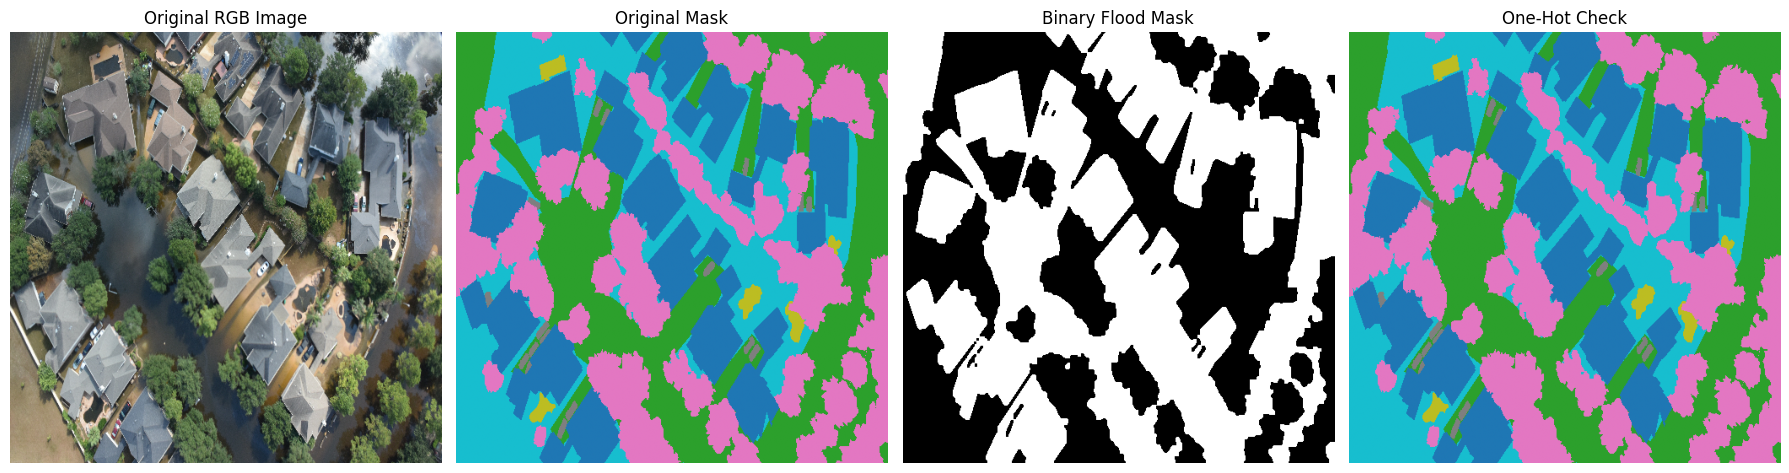

In [9]:
# loop through all images and masks 
def load_example(image_path, mask_path):
    
    # read RGB image 
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0

    # normalize image using the training mean and std
    image = (image - train_mean) / train_std

    # read mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)

    # use nearest neighbor resize so class values stay intact
    mask = tf.image.resize(mask, [IMG_HEIGHT, IMG_WIDTH], method = "nearest")
    mask = tf.cast(mask, tf.int32)
    mask = tf.squeeze(mask, axis=-1)

    # one hot encode mask
    one_hot_mask = tf.one_hot(mask, depth=NUM_CLASSES, dtype=tf.float32)

    # create finary flood mask
    flood_mask = tf.cast(
        tf.logical_or(tf.equal(mask, 1), tf.equal(mask, 3)),
        tf.float32
    )

    # apply smoothing to the flood mask
    flood_mask = tf.numpy_function(smooth_flood_mask, [flood_mask], tf.float32)

    # set the shape again
    flood_mask.set_shape([IMG_HEIGHT, IMG_WIDTH])

    # create binary image label (1 if any flooded pixel exists)
    binary_label = tf.cast(tf.reduce_any(flood_mask > 0), tf.float32)
    return image, mask, one_hot_mask, flood_mask, binary_label

# preview example 
sample_img_path, sample_mask_path = train_pairs[250] # image 249
image, mask, one_hot_mask, flood_mask, binary_label = load_example(sample_img_path, sample_mask_path)
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("One-hot shape:", one_hot_mask.shape)
print("Flood mask shape:", flood_mask.shape)
print("Binary label:", binary_label.numpy())

# plot example
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
display_img = image.numpy() * train_std + train_mean
display_img = np.clip(display_img, 0, 1)
axes[0].imshow(display_img)
axes[0].set_title("Original RGB Image")
axes[0].axis("off")
axes[1].imshow(mask.numpy(), cmap="tab10")
axes[1].set_title("Original Mask")
axes[1].axis("off")
axes[2].imshow(flood_mask.numpy(), cmap="gray")
axes[2].set_title("Binary Flood Mask")
axes[2].axis("off")
axes[3].imshow(tf.argmax(one_hot_mask, axis=-1).numpy(), cmap="tab10")
axes[3].set_title("One-Hot Check")
axes[3].axis("off")
plt.tight_layout()
plt.show()

##### Classification Parser

In [10]:
# define function
def classification_parser(image_path, mask_path):
    
    # load the full example
    image, mask, one_hot_mask, flood_mask, binary_label = load_example(image_path, mask_path)

    # for classification, only return: the RGB image, the binary image level label
    return image, binary_label

##### Split Paths into Image and Mask Lists

In [11]:
# train
train_img_paths = [x[0] for x in train_pairs]
train_mask_paths = [x[1] for x in train_pairs]

# validation
val_img_paths = [x[0] for x in val_pairs]
val_mask_paths = [x[1] for x in val_pairs]

# test
test_img_paths = [x[0] for x in test_pairs]
test_mask_paths = [x[1] for x in test_pairs]

##### Training Dataset

In [12]:
# define training dataset
train_ds = tf.data.Dataset.from_tensor_slices((train_img_paths, train_mask_paths))

# convert each image_path, mask_path pair into image_tensor, binary_label
train_ds = train_ds.map(classification_parser, num_parallel_calls=tf.data.AUTOTUNE)

# shuffle only the training set
train_ds = train_ds.shuffle(len(train_img_paths), seed=SEED)

# group into batches and prefetch
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

##### Validation Dataset

In [13]:
# define validation dataset
val_ds = tf.data.Dataset.from_tensor_slices((val_img_paths, val_mask_paths))

# convert file paths into tensors
val_ds = val_ds.map(classification_parser, num_parallel_calls=tf.data.AUTOTUNE)

# batch and prefetch
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

##### Test Dataset

In [14]:
# define test dataset
test_ds = tf.data.Dataset.from_tensor_slices((test_img_paths, test_mask_paths))

# convert file paths into tensors
test_ds = test_ds.map(classification_parser, num_parallel_calls=tf.data.AUTOTUNE)

# batch and prefetch
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

##### Build Model

In [15]:
# function to build model
def build_model(backbone_name="resnet50"):
    
    # choose which pretrained backbone to use
    if backbone_name == "resnet50":
        base_model = tf.keras.applications.ResNet50(
            include_top=False,
            weights="imagenet",
            input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
        )
    elif backbone_name == "resnet101":
        base_model = tf.keras.applications.ResNet101(
            include_top=False,
            weights="imagenet",
            input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
        )
    else:
        raise ValueError("backbone_name must be 'resnet50' or 'resnet101'")

    # freeze the pretrained base at first
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # final output for binary classification
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )
    return model, base_model

### ResNet50

In [16]:
# resnet50 experiement
model, base_model = build_model(backbone_name="resnet50")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 16, 16, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

##### Callbacks

In [17]:
# callbacks if needed
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

##### Model Training and Fine Tuning

Epoch 1/20


I0000 00:00:1777682109.222468 10338045 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1011 of 1445
I0000 00:00:1777682113.094520 10338045 shuffle_dataset_op.cc:483] Shuffle buffer filled.


181/181 ━━━━━━━━━━━━━━━━━━━━ 132s 645ms/step - accuracy: 0.9190 - loss: 0.2358 - precision: 0.7400 - recall: 0.4485 - val_accuracy: 0.9533 - val_loss: 0.1221 - val_precision: 1.0000 - val_recall: 0.6111 - learning_rate: 0.0010
Epoch 2/20


I0000 00:00:1777682239.706120 10342116 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1033 of 1445
I0000 00:00:1777682243.354613 10342116 shuffle_dataset_op.cc:483] Shuffle buffer filled.


181/181 ━━━━━━━━━━━━━━━━━━━━ 127s 629ms/step - accuracy: 0.9557 - loss: 0.1349 - precision: 0.9040 - recall: 0.6848 - val_accuracy: 0.9711 - val_loss: 0.0899 - val_precision: 0.9767 - val_recall: 0.7778 - learning_rate: 0.0010
Epoch 3/20


...

181/181 ━━━━━━━━━━━━━━━━━━━━ 159s 806ms/step - accuracy: 1.0000 - loss: 0.0032 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9867 - val_loss: 0.0328 - val_precision: 0.9615 - val_recall: 0.9259 - learning_rate: 5.0000e-06
Epoch 7/10


I0000 00:00:1777685624.926769 10398540 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1110 of 1445
I0000 00:00:1777685627.769084 10398540 shuffle_dataset_op.cc:483] Shuffle buffer filled.


181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.9995 - loss: 0.0030 - precision: 0.9945 - recall: 0.9898
Epoch 7: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
181/181 ━━━━━━━━━━━━━━━━━━━━ 159s 809ms/step - accuracy: 0.9986 - loss: 0.0039 - precision: 1.0000 - recall: 0.9879 - val_accuracy: 0.9822 - val_loss: 0.0334 - val_precision: 0.9259 - val_recall: 0.9259 - learning_rate: 5.0000e-06
Epoch 8/10


I0000 00:00:1777685784.197855 10401101 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1089 of 1445
I0000 00:00:1777685787.225936 10401101 shuffle_dataset_op.cc:483] Shuffle buffer filled.


181/181 ━━━━━━━━━━━━━━━━━━━━ 159s 810ms/step - accuracy: 0.9993 - loss: 0.0034 - precision: 1.0000 - recall: 0.9939 - val_accuracy: 0.9844 - val_loss: 0.0313 - val_precision: 0.9434 - val_recall: 0.9259 - learning_rate: 2.5000e-06


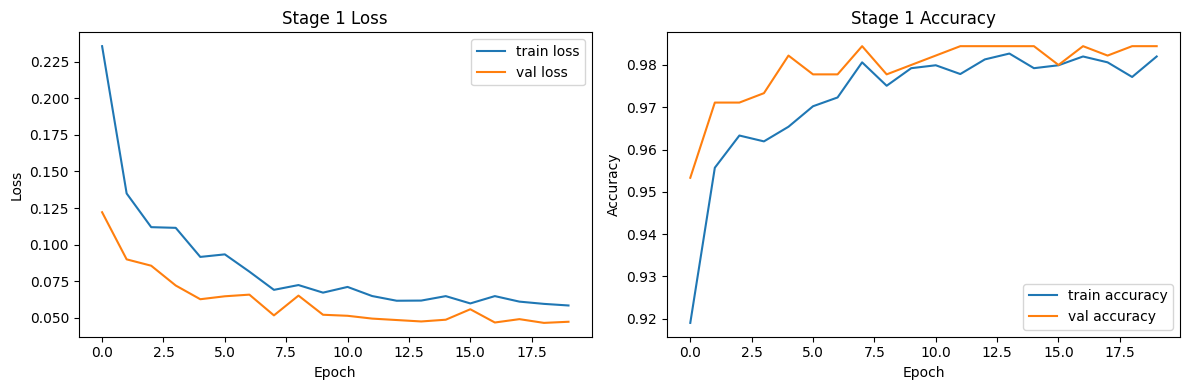

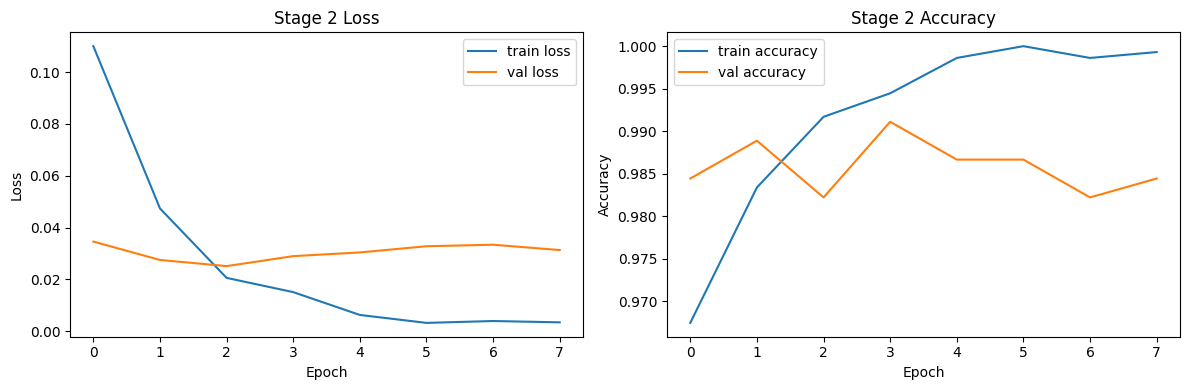

In [18]:
# train with base ResNet frozen
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr]
)

# unfreeze base model
base_model.trainable = True

# keep earlier layers frozen and only fine tune the later layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# recompile after changing trainable layers
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# continue training
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

# plot training history 
def plot_history(history, title_text):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="val loss")
    plt.title(title_text + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="train accuracy")
    plt.plot(history.history["val_accuracy"], label="val accuracy")
    plt.title(title_text + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_history(history1, "Stage 1")
plot_history(history2, "Stage 2")

##### Evaluate on Train, Validation, and Test Sets

In [19]:
# evaluate ResNet50 on train, validation, and test sets
# monitored val_loss, making val a tuning signal rather than a held-out estimate.
# test accuracy is the only unbiased measure of generalization.
train_results  = model.evaluate(train_ds, verbose=0)
val_results    = model.evaluate(val_ds,   verbose=0)
test_results   = model.evaluate(test_ds,  verbose=0)

print("\nResNet50 Results")
print(f"{'Dataset':<12} {'Loss':>8} {'Accuracy':>10} {'Precision':>11} {'Recall':>8}")
print("-" * 55)
for label, results in [("Train", train_results), ("Validation", val_results), ("Test", test_results)]:
    print(f"{label:<12} {results[0]:>8.4f} {results[1]:>10.4f} {results[2]:>11.4f} {results[3]:>8.4f}")

I0000 00:00:1777685965.957905 10404245 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1051 of 1445
I0000 00:00:1777685969.386803 10404245 shuffle_dataset_op.cc:483] Shuffle buffer filled.



ResNet50 Results
Dataset          Loss   Accuracy   Precision   Recall
-------------------------------------------------------
Train          0.0043     0.9986      0.9939   0.9939
Validation     0.0251     0.9822      0.9259   0.9259
Test           0.0194     0.9955      0.9808   0.9808


##### Confusion Matrix


Confusion Matrix
[[395   1]
 [  1  51]]

F1 Score
0.9807692307692307

Classification Report
              precision    recall  f1-score   support

           0     0.9975    0.9975    0.9975       396
           1     0.9808    0.9808    0.9808        52

    accuracy                         0.9955       448
   macro avg     0.9891    0.9891    0.9891       448
weighted avg     0.9955    0.9955    0.9955       448



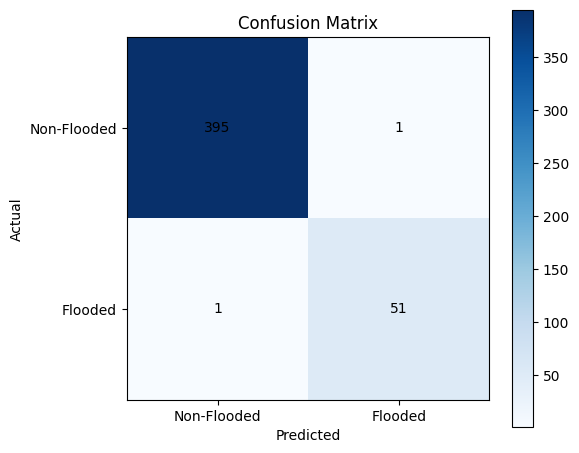

In [20]:
# predictions for confusion matrix
y_true = []
y_pred_prob = []

# loop through the test dataset batch by batch
for batch_images, batch_labels in test_ds:
    preds = model.predict(batch_images, verbose=0)

    # store true labels and predicted probabilities
    y_true.extend(batch_labels.numpy().astype(int).tolist())
    y_pred_prob.extend(preds.flatten().tolist())

# convert lists into numpy arrays 
y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Convert probabilities into binary predictions
y_pred = (y_pred_prob >= 0.5).astype(int)

# compute evaluation metrics
cm = confusion_matrix(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# print results
print("\nConfusion Matrix")
print(cm)
print("\nF1 Score")
print(f1)
print("\nClassification Report")
print(classification_report(y_true, y_pred, digits=4))

# plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Non-Flooded", "Flooded"])
plt.yticks([0, 1], ["Non-Flooded", "Flooded"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.show()

### ResNet101

In [21]:
# build second model
model2, base_model2 = build_model(backbone_name="resnet101")
model2.summary()

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet101 (Functional)          │ (None, 16, 16, 2048)   │    42,658,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,660,225 (162.74 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 42,658,176 (162.73 MB)

##### Callbacks

In [22]:
# callbacks for second model
early_stop_model2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
reduce_lr_model2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

##### Model Training and Fine Tuning

Epoch 1/20


I0000 00:00:1777686186.279098 10408275 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1036 of 1445
I0000 00:00:1777686189.761553 10408275 shuffle_dataset_op.cc:483] Shuffle buffer filled.


181/181 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.9163 - loss: 0.2344 - precision: 0.7391 - recall: 0.4121 - val_accuracy: 0.9556 - val_loss: 0.1245 - val_precision: 0.8864 - val_recall: 0.7222 - learning_rate: 0.0010
Epoch 2/20


I0000 00:00:1777686398.870187 10410518 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1073 of 1445
I0000 00:00:1777686402.116847 10410518 shuffle_dataset_op.cc:483] Shuffle buffer filled.


181/181 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.9578 - loss: 0.1269 - precision: 0.9127 - recall: 0.6970 - val_accuracy: 0.9689 - val_loss: 0.0924 - val_precision: 0.9348 - val_recall: 0.7963 - learning_rate: 0.0010
Epoch 3/20


...

181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 987ms/step - accuracy: 1.0000 - loss: 0.0031 - precision: 0.9834 - recall: 0.9834
Epoch 8: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
181/181 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 1.0000 - loss: 0.0027 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9889 - val_loss: 0.0343 - val_precision: 0.9804 - val_recall: 0.9259 - learning_rate: 1.0000e-05
Epoch 9/10


I0000 00:00:1777692760.636332 10473734 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1114 of 1445
I0000 00:00:1777692763.400119 10473734 shuffle_dataset_op.cc:483] Shuffle buffer filled.


181/181 ━━━━━━━━━━━━━━━━━━━━ 244s 1s/step - accuracy: 1.0000 - loss: 0.0034 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9889 - val_loss: 0.0347 - val_precision: 0.9804 - val_recall: 0.9259 - learning_rate: 5.0000e-06
Epoch 10/10


I0000 00:00:1777693004.564287 10475750 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1118 of 1445
I0000 00:00:1777693007.316965 10475750 shuffle_dataset_op.cc:483] Shuffle buffer filled.


181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 983ms/step - accuracy: 1.0000 - loss: 0.0019 - precision: 0.9890 - recall: 0.9890
Epoch 10: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
181/181 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 1.0000 - loss: 0.0016 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9911 - val_loss: 0.0353 - val_precision: 0.9808 - val_recall: 0.9444 - learning_rate: 5.0000e-06


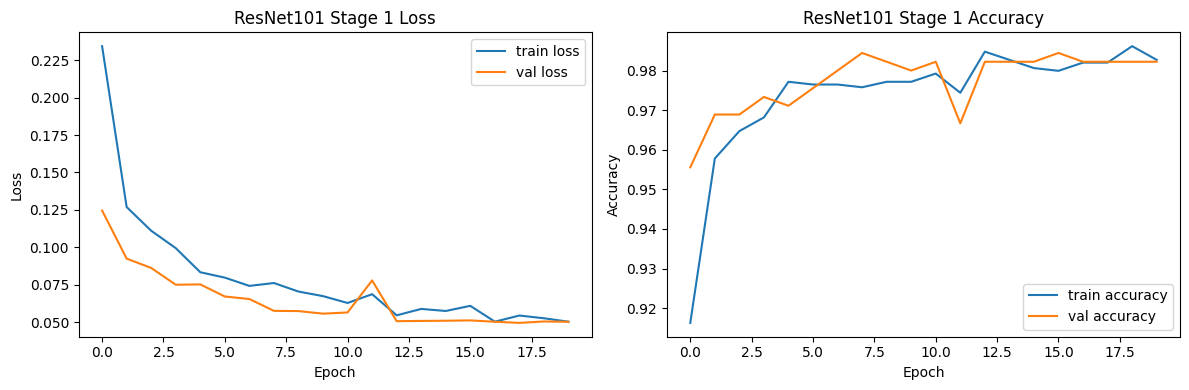

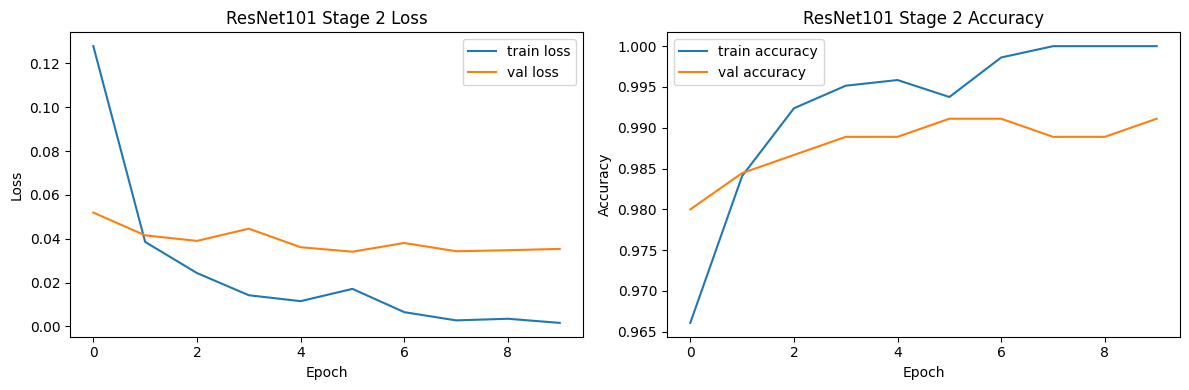

In [23]:
# train second model with base ResNet frozen
history1_model2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop_model2, reduce_lr_model2]
)

# unfreeze base model
base_model2.trainable = True

# keep earlier layers frozen and only fine tune the later layers
for layer in base_model2.layers[:-30]:
    layer.trainable = False

# recompile after changing trainable layers
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# continue training
history2_model2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop_model2, reduce_lr_model2]
)

# plot training history
plot_history(history1_model2, "ResNet101 Stage 1")
plot_history(history2_model2, "ResNet101 Stage 2")

##### Evaluate on Train, Validation, and Test Sets

In [24]:
# evaluate ResNet101 on train, validation, and test sets
# note: validation accuracy is optimistic — early stopping and LR scheduling both
# monitored val_loss, making val a tuning signal rather than a held-out estimate.
# test accuracy is the only unbiased measure of generalization.
train_results_model2  = model2.evaluate(train_ds, verbose=0)
val_results_model2    = model2.evaluate(val_ds,   verbose=0)
test_results_model2   = model2.evaluate(test_ds,  verbose=0)

print("\nResNet101 Results")
print(f"{'Dataset':<12} {'Loss':>8} {'Accuracy':>10} {'Precision':>11} {'Recall':>8}")
print("-" * 55)
for label, results in [("Train", train_results_model2), ("Validation", val_results_model2), ("Test", test_results_model2)]:
    print(f"{label:<12} {results[0]:>8.4f} {results[1]:>10.4f} {results[2]:>11.4f} {results[3]:>8.4f}")

I0000 00:00:1777693269.518971 10478146 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1043 of 1445
I0000 00:00:1777693273.069947 10478146 shuffle_dataset_op.cc:483] Shuffle buffer filled.



ResNet101 Results
Dataset          Loss   Accuracy   Precision   Recall
-------------------------------------------------------
Train          0.0016     0.9993      0.9940   1.0000
Validation     0.0341     0.9911      0.9808   0.9444
Test           0.0307     0.9955      1.0000   0.9615


##### Confusion Matrix


ResNet101 Confusion Matrix
[[396   0]
 [  2  50]]

ResNet101 F1 Score
0.9803921568627451

ResNet101 Classification Report
              precision    recall  f1-score   support

           0     0.9950    1.0000    0.9975       396
           1     1.0000    0.9615    0.9804        52

    accuracy                         0.9955       448
   macro avg     0.9975    0.9808    0.9889       448
weighted avg     0.9956    0.9955    0.9955       448



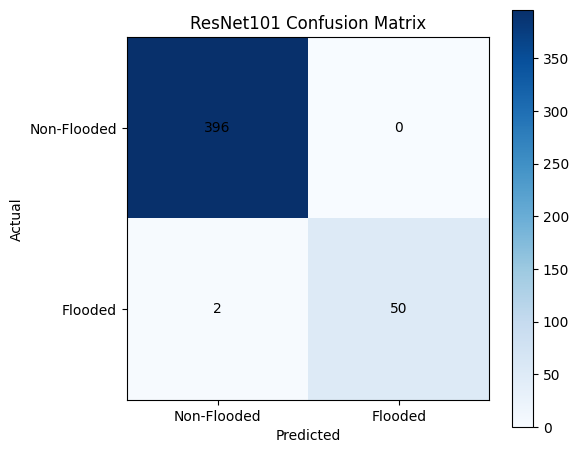

In [25]:
# predictions for confusion matrix
y_true_model2 = []
y_pred_prob_model2 = []

# loop through the test dataset by batch
for batch_images, batch_labels in test_ds:
    preds = model2.predict(batch_images, verbose=0)

    # store true labels and predicted probabilities
    y_true_model2.extend(batch_labels.numpy().astype(int).tolist())
    y_pred_prob_model2.extend(preds.flatten().tolist())

# convert lists into numpy arrays
y_true_model2 = np.array(y_true_model2)
y_pred_prob_model2 = np.array(y_pred_prob_model2)

# convert probabilities into binary predictions
y_pred_model2 = (y_pred_prob_model2 >= 0.5).astype(int)

# compute evaluation metrics
cm_model2 = confusion_matrix(y_true_model2, y_pred_model2)
f1_model2 = f1_score(y_true_model2, y_pred_model2)

# print results
print("\nResNet101 Confusion Matrix")
print(cm_model2)
print("\nResNet101 F1 Score")
print(f1_model2)
print("\nResNet101 Classification Report")
print(classification_report(y_true_model2, y_pred_model2, digits=4))

# plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm_model2, cmap="Blues")
plt.title("ResNet101 Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Non-Flooded", "Flooded"])
plt.yticks([0, 1], ["Non-Flooded", "Flooded"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm_model2.shape[0]):
    for j in range(cm_model2.shape[1]):
        plt.text(j, i, str(cm_model2[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

### ResNet50 and ResNet101 Comparison

In [26]:
# ── Quantitative comparison ──────────────────────────────────────────────────
print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print("\nConfusion Matrices")
print(f"{'ResNet50':<35} {'ResNet101':<35}")
for row50, row101 in zip(cm, cm_model2):
    print(f"  {str(row50):<33}   {str(row101):<33}")

print(f"\n{'Model':<12} {'Train Acc':>10} {'Val Acc':>9} {'Test Acc':>9} {'F1 (Test)':>10}")
print("-" * 55)
print(f"{'ResNet50':<12} {train_results[1]:>10.4f} {val_results[1]:>9.4f} {test_results[1]:>9.4f} {f1:>10.4f}")
print(f"{'ResNet101':<12} {train_results_model2[1]:>10.4f} {val_results_model2[1]:>9.4f} {test_results_model2[1]:>9.4f} {f1_model2:>10.4f}")

FINAL MODEL COMPARISON

Confusion Matrices
ResNet50                            ResNet101                          
  [395   1]                           [396   0]                        
  [ 1 51]                             [ 2 50]                          

Model         Train Acc   Val Acc  Test Acc  F1 (Test)
-------------------------------------------------------
ResNet50         0.9986    0.9822    0.9955     0.9808
ResNet101        0.9993    0.9911    0.9955     0.9804
